# OSRS NPC Classification
# Challenger model -- custom CNN, trained from scratch

Champion-challenger companion to `03a_train_champion_local.ipynb`. Same task, same data, same
70/15/15 split (shared via `npc_data.py` so the two models are compared on identical rows), same
fusion head and training loop shape -- the **only** thing that changes is the backbone: instead
of two pretrained ResNet18s, this notebook hand-builds two CNNs from scratch (random init, no
ImageNet weights). Isolating that one variable is what makes the champion vs. challenger
comparison in `04c_classification_comparison.ipynb` a fair "transfer learning vs. from-scratch"
comparison rather than a comparison of two unrelated design choices.

- **Input:** chathead image + body image (separate CNN backbones, concatenated features)
- **Target:** Class (top 10 classes, everything else collapsed to "Other")
- **Split:** 70/15/15 train/val/test, stratified, `random_state=42` (identical split to the champion)
- **Backbone (challenger):** two from-scratch 5-block Conv-BatchNorm-ReLU-MaxPool CNNs, each
  producing a 512-dim feature vector -- matched to ResNet18's 512-dim output so the fusion head
  is architecturally identical to the champion's.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from npc_data import (
    load_clean_npc_df, add_top_class_labels, stratified_split,
    get_transforms, NPCDataset, class_weights,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cuda


In [2]:
df = load_clean_npc_df(data_dir="../data")
print(f"Working dataset: {len(df)} NPCs")

df, CLASS_NAMES, class_to_idx = add_top_class_labels(df, n=10)
print(df["label"].value_counts())

Working dataset: 3459 NPCs
label
Human         2095
Other          575
Dwarf          248
Elf            149
Gnome          139
Vampyre         61
Ghost           49
Monkey          42
Dorgeshuun      40
Troll           31
Cat             30
Name: count, dtype: int64


## Split data into training/val/test (identical to the champion notebook)

In [3]:
train_df, val_df, test_df = stratified_split(df, seed=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 2421 | Val: 519 | Test: 519


In [4]:
train_transform, eval_transform = get_transforms(img_size=128)
MINORITY_CLASSES = set(CLASS_NAMES) - {"Human", "Other"}

train_ds = NPCDataset(train_df, train_transform, data_dir="../data", is_train=True, minority_classes=MINORITY_CLASSES)
val_ds = NPCDataset(val_df, eval_transform, data_dir="../data", is_train=False)
test_ds = NPCDataset(test_df, eval_transform, data_dir="../data", is_train=False)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=32, num_workers=0)

## Model architecture -- challenger (from scratch)

### Backbone
Five `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d` blocks per branch (channels 3->32->64->128->256->512),
followed by global average pooling -- 128x128 input collapses through five stride-2 pools to a
4x4x512 feature map, pooled to a 512-dim vector. No pretrained weights; every parameter starts
from random init and is learned entirely from this dataset.

### Fusion
Identical to the champion: concatenate the two 512-dim vectors (1024-dim) ->
Linear(1024->256) -> ReLU -> Dropout(0.5) -> Linear(256->n_classes).

### Training
- **Loss:** CrossEntropyLoss with inverse-frequency class weights (same as champion)
- **Optimizer:** Adam, lr=1e-3 (higher than the champion's 5e-5 -- from-scratch weights need much
  bigger updates than fine-tuning an already-good pretrained representation) + weight_decay=1e-4
  to help offset the lack of an ImageNet prior
- **Scheduler:** ReduceLROnPlateau (halves LR if val loss plateaus for 2 epochs)
- **Early stopping:** patience=5 (looser than the champion's 3 -- from-scratch convergence is
  slower and noisier early on), saves best checkpoint
- **Input size:** 128x128 (same as champion)

In [5]:
def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
    )


class ScratchCNNBackbone(nn.Module):
    """From-scratch conv backbone -- no pretrained weights. Output dim matched to
    ResNet18's 512 so it's a drop-in replacement in the fusion head below.
    """

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 512),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return x.flatten(1)


class ScratchDualCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.chathead_cnn = ScratchCNNBackbone()
        self.body_cnn = ScratchCNNBackbone()
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, chathead, body):
        f1 = self.chathead_cnn(chathead)
        f2 = self.body_cnn(body)
        return self.classifier(torch.cat([f1, f2], dim=1))


def run_epoch(model, loader, criterion, optimizer, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for chathead, body, labels in loader:
            chathead, body, labels = chathead.to(DEVICE), body.to(DEVICE), labels.to(DEVICE)
            preds = model(chathead, body)
            loss = criterion(preds, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            correct += (preds.argmax(1) == labels).sum().item()
            total += len(labels)
    return total_loss / len(loader), correct / total

In [6]:
model = ScratchDualCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)

weights = class_weights(df, len(CLASS_NAMES), DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

n_params = sum(p.numel() for p in model.parameters())
print(f"Challenger (ScratchDualCNN, from-scratch backbones) params: {n_params:,}")

Challenger (ScratchDualCNN, from-scratch backbones) params: 3,406,347


In [7]:
CHECKPOINT_PATH = "../data/custom_cnn_classifier.pth"

best_val_loss = float("inf")
patience = 5
epochs_no_improve = 0
history = []

EPOCHS = 60
for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer, train=False)
    history.append((epoch + 1, train_loss, train_acc, val_loss, val_acc))
    print(f"Epoch {epoch+1}/{EPOCHS} | train loss: {train_loss:.3f} acc: {train_acc:.3f} | val loss: {val_loss:.3f} acc: {val_acc:.3f}")
    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        epochs_no_improve = 0
        print("  saved best model")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping.")
            break

C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/60 | train loss: 2.358 acc: 0.144 | val loss: 2.017 acc: 0.358
  saved best model


Epoch 2/60 | train loss: 2.060 acc: 0.248 | val loss: 1.734 acc: 0.343
  saved best model


Epoch 3/60 | train loss: 1.890 acc: 0.293 | val loss: 1.815 acc: 0.507


Epoch 4/60 | train loss: 1.820 acc: 0.301 | val loss: 1.521 acc: 0.358
  saved best model


...

Epoch 27/60 | train loss: 0.944 acc: 0.597 | val loss: 0.902 acc: 0.599


Epoch 28/60 | train loss: 1.028 acc: 0.574 | val loss: 0.934 acc: 0.622


Epoch 29/60 | train loss: 0.944 acc: 0.594 | val loss: 0.917 acc: 0.385


Epoch 30/60 | train loss: 0.923 acc: 0.606 | val loss: 0.890 acc: 0.663


Epoch 31/60 | train loss: 0.859 acc: 0.620 | val loss: 0.880 acc: 0.661
Early stopping.


In [8]:
model.load_state_dict(torch.load(CHECKPOINT_PATH))

test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer, train=False)
print(f"Challenger test accuracy: {test_acc:.3f}")

Challenger test accuracy: 0.618


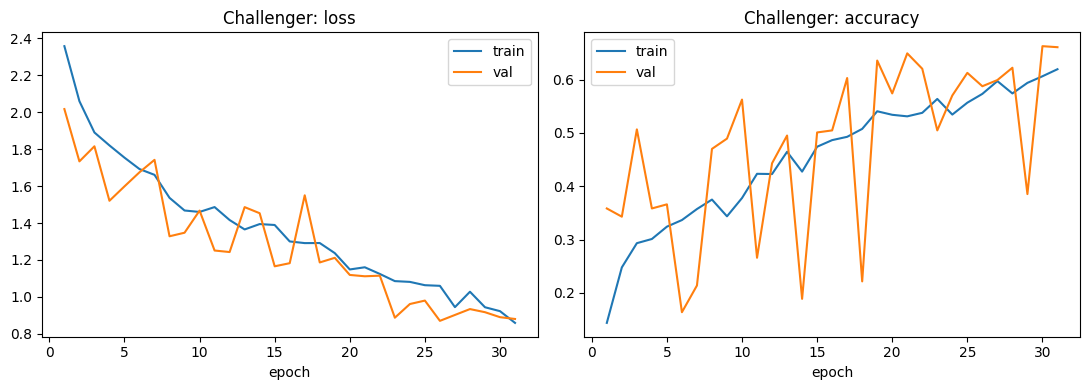

In [9]:
epochs_r, train_losses, train_accs, val_losses, val_accs = zip(*history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs_r, train_losses, label="train")
axes[0].plot(epochs_r, val_losses, label="val")
axes[0].set_title("Challenger: loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(epochs_r, train_accs, label="train")
axes[1].plot(epochs_r, val_accs, label="val")
axes[1].set_title("Challenger: accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig("../img/challenger_training_curves.png")
plt.show()